# XGBoost Pass Detection Model - Step by Step

This notebook walks through building a pass detection model using XGBoost.
We'll explore the data, train the model, evaluate it on three splits, and
interpret the results.

**Goal:** Predict whether a 0.5-second window of tracking data contains
a pass event.

This notebook is for learning and visualization only. It does not save
model artifacts, report JSON, or plot image files. The production script
that generates files is `src/driblab/models/pass_detector.py`.

In [42]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

np.random.seed(42)
sns.set_theme(style="white")


def keep_main_axes(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

print("All libraries imported successfully")
print(PROJECT_ROOT)

All libraries imported successfully
/Users/nataliaurrea/Documents/IE/MBDS/Term III/Driblab


In [43]:
train_df = pd.read_parquet(
    PROJECT_ROOT / "data/processed/model_base/training_table_train.parquet"
)
val_df = pd.read_parquet(
    PROJECT_ROOT / "data/processed/model_base/training_table_validation.parquet"
)
test_df = pd.read_parquet(
    PROJECT_ROOT / "data/processed/model_base/training_table_test.parquet"
)

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (279437, 10)
Validation: (59372, 10)
Test: (58488, 10)


## Data Overview

Let's check the pass rate, or class distribution, in each split to make
sure the train, validation, and test sets are representative.

PASS RATE BY SPLIT

Train:
  Pass windows:    88,363 (31.62%)
  No-pass windows: 191,074 (68.38%)

Validation:
  Pass windows:    20,073 (33.81%)
  No-pass windows: 39,299 (66.19%)

Test:
  Pass windows:    21,108 (36.09%)
  No-pass windows: 37,380 (63.91%)



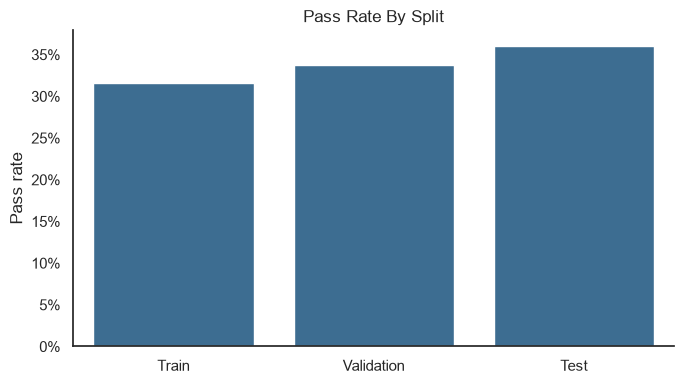

In [44]:
print("PASS RATE BY SPLIT\n")
distribution_rows = []

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    pass_rate = df["is_pass"].mean()
    pass_count = int(df["is_pass"].sum())
    no_pass_count = int((df["is_pass"] == 0).sum())
    distribution_rows.append(
        {
            "split": name,
            "pass_windows": pass_count,
            "no_pass_windows": no_pass_count,
            "pass_rate": pass_rate,
            "no_pass_rate": 1 - pass_rate,
        }
    )
    print(f"{name}:")
    print(f"  Pass windows:    {pass_count:,} ({pass_rate:.2%})")
    print(f"  No-pass windows: {no_pass_count:,} ({1-pass_rate:.2%})")
    print()

distribution_df = pd.DataFrame(distribution_rows)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=distribution_df,
    x="split",
    y="pass_rate",
    color="#2f6f9f",
    ax=ax,
)
ax.set_title("Pass Rate By Split")
ax.set_xlabel("")
ax.set_ylabel("Pass rate")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
keep_main_axes(ax)
plt.tight_layout()
plt.show()

**Interpretation**

- Pass rates are consistent across splits.
- This means the split strategy is producing comparable train,
  validation, and test sets.
- No-pass windows are much more common than pass windows. That class
  imbalance is expected for event detection in continuous tracking data.

In [45]:
FEATURES = [
    "ball_speed_avg_xy",
    "closest_player_team_id",
]

TARGET = "is_pass"

print(f"Total features: {len(FEATURES)}")
print("\nFeatures:")
print("  Ball movement:  ball_speed_avg_xy")
print("  Player context: closest_player_team_id  (label-encoded; NaN → 0 for no-event windows)")

Total features: 2

Features:
  Ball movement:  ball_speed_avg_xy
  Player context: closest_player_team_id  (label-encoded; NaN → 0 for no-event windows)


In [46]:
def _encode_features(df, features):
    """Encode features to float: numeric columns are cast directly,
    non-numeric (e.g. ArrowString team IDs) are label-encoded.
    NaN values (including no-event windows) become 0 after fillna."""
    encoded = {}
    for col in features:
        series = df[col]
        if pd.api.types.is_numeric_dtype(series):
            encoded[col] = series.to_numpy(dtype=float, na_value=np.nan)
        else:
            codes = pd.Categorical(series).codes.astype(float)
            codes[codes == -1] = np.nan
            encoded[col] = codes
    return pd.DataFrame(encoded, index=df.index).fillna(0)


X_train = _encode_features(train_df, FEATURES)
y_train = train_df[TARGET].astype(int)

X_val = _encode_features(val_df, FEATURES)
y_val = val_df[TARGET].astype(int)

X_test = _encode_features(test_df, FEATURES)
y_test = test_df[TARGET].astype(int)

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURES)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=FEATURES)

print(f"Training data:   {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Validation data: {X_val.shape[0]:,} rows x {X_val.shape[1]} features")
print(f"Test data:       {X_test.shape[0]:,} rows x {X_test.shape[1]} features")

Training data:   279,437 rows x 2 features
Validation data: 59,372 rows x 2 features
Test data:       58,488 rows x 2 features


## Model Hyperparameters

These are the settings used for XGBoost:

- **objective:** `binary:logistic` means binary classification, pass or
  no pass.
- **eval_metric:** `logloss` watches probability quality during
  training.
- **max_depth:** `5` controls how deep each tree can grow.
- **learning_rate:** `0.1` controls how much each tree contributes.
- **early_stopping_rounds:** `20` stops training if validation loss does
  not improve for 20 rounds.

The validation set monitors generalization while training.

In [47]:
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 5,
    "learning_rate": 0.1,
    "random_state": 42,
}

print("XGBoost Parameters:")
for key, value in params.items():
    print(f"  {key}: {value}")

XGBoost Parameters:
  objective: binary:logistic
  eval_metric: logloss
  max_depth: 5
  learning_rate: 0.1
  random_state: 42


## Training the Model

Now we'll train XGBoost on the training data, using validation data to
monitor for overfitting.

The model prints progress every 50 rounds. You will see:

- `train` loss: how well the model fits training data
- `validation` loss: how well it generalizes to unseen data

Good sign: both losses decrease over time. Bad sign: validation loss
increases while train loss keeps decreasing.

In [48]:
print("Training XGBoost model...\n")

model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=20,
    verbose_eval=50,
)

print("\nTraining complete!")
print(f"Best iteration: {model.best_iteration + 1} (of 200 possible)")

Training XGBoost model...

[0]	train-logloss:0.59221	validation-logloss:0.60882
[47]	train-logloss:0.45728	validation-logloss:0.48526

Training complete!
Best iteration: 28 (of 200 possible)


**Interpretation**

The best iteration is the point where validation loss was strongest.
Early stopping avoids continuing into rounds that fit the training data
more tightly without improving validation performance.

In [49]:
def evaluate_split(name, dmatrix, y_true):
    y_pred_proba = model.predict(dmatrix)
    y_pred = (y_pred_proba > 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n{name.upper()} SET EVALUATION")
    print("=" * 50)
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print("\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:,}")
    print(f"  False Positives: {fp:,}")
    print(f"  False Negatives: {fn:,}")
    print(f"  True Positives:  {tp:,}")

    return {
        "accuracy": acc,
        "f1": f1,
        "roc_auc": auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }


train_results = evaluate_split("train", dtrain, y_train)
val_results = evaluate_split("validation", dval, y_val)
test_results = evaluate_split("test", dtest, y_test)

metrics_df = pd.DataFrame(
    [
        {"split": "Train", **{k: train_results[k] for k in ["accuracy", "f1", "roc_auc"]}},
        {"split": "Validation", **{k: val_results[k] for k in ["accuracy", "f1", "roc_auc"]}},
        {"split": "Test", **{k: test_results[k] for k in ["accuracy", "f1", "roc_auc"]}},
    ]
)
display(metrics_df)


TRAIN SET EVALUATION
Accuracy:  0.8210
F1-Score:  0.6824
ROC-AUC:   0.8050

Confusion Matrix:
  True Negatives:  175,678
  False Positives: 15,396
  False Negatives: 34,620
  True Positives:  53,743

VALIDATION SET EVALUATION
Accuracy:  0.8055
F1-Score:  0.6733
ROC-AUC:   0.7912

Confusion Matrix:
  True Negatives:  35,921
  False Positives: 3,378
  False Negatives: 8,172
  True Positives:  11,901

TEST SET EVALUATION
Accuracy:  0.7752
F1-Score:  0.6192
ROC-AUC:   0.7349

Confusion Matrix:
  True Negatives:  34,650
  False Positives: 2,730
  False Negatives: 10,419
  True Positives:  10,689


,split,accuracy,f1,roc_auc
0,Train,0.821012,0.682442,0.805020
1,Validation,0.805464,0.673286,0.791172
2,Test,0.775185,0.619168,0.734865


## Understanding the Metrics

**Accuracy:** What percentage of predictions were correct?

- Formula: `(TP + TN) / Total`
- Useful, but can be misleading with imbalanced data because no-pass
  windows are much more common.

**F1-Score:** Balance between precision and recall.

- Precision: of predicted passes, how many were actually passes?
- Recall: of actual passes, how many did we catch?
- F1 is their harmonic mean.

**ROC-AUC:** How well does the model separate pass from no-pass?

- `0.5` means random ranking.
- `1.0` means perfect ranking.
- This is especially useful with class imbalance.

### Interpretation

Compare train, validation, and test. Similar values across splits mean
the model is generalizing rather than only memorizing the training data.

TOP 10 MOST IMPORTANT FEATURES

               feature  importance
     ball_speed_avg_xy       784.0
closest_player_team_id       377.0


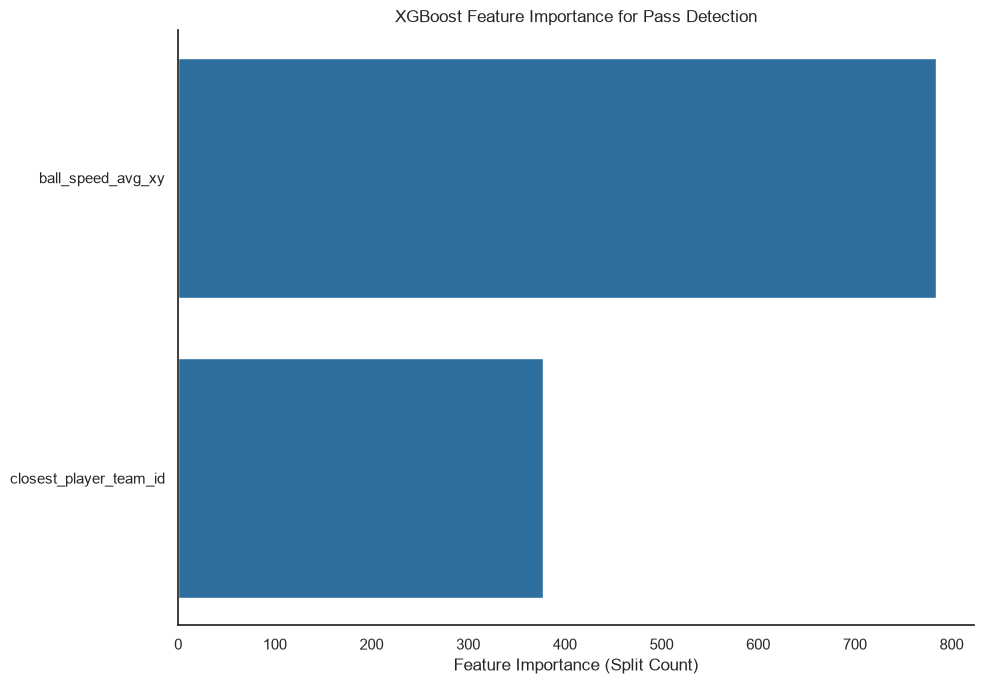

In [50]:
importance_dict = model.get_score(importance_type="weight")
importance_df = pd.DataFrame(
    [
        {"feature": feat, "importance": importance_dict.get(feat, 0)}
        for feat in FEATURES
    ]
).sort_values("importance", ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES\n")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 7))
plot_df = importance_df.sort_values("importance", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance"], color="#2f6f9f")
plt.xlabel("Feature Importance (Split Count)")
plt.title("XGBoost Feature Importance for Pass Detection")
keep_main_axes(plt.gca())
plt.tight_layout()
plt.show()

## What Feature Importance Means

Feature importance shows how often each feature is used to make splits
in the decision trees. Higher values mean the feature was used more
often.

Look for which feature families dominate:

- Ball movement can signal pass-like action.
- Player proximity can show who is near the ball at the start and end.
- Context features add directional and team-change information.

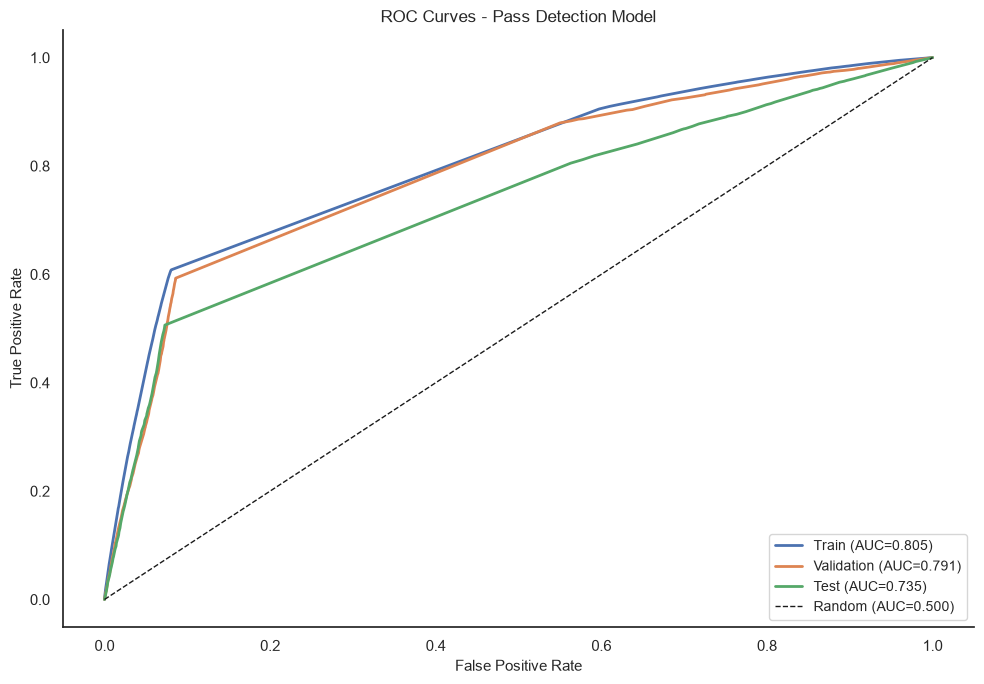

In [51]:
plt.figure(figsize=(10, 7))

for name, dmatrix, y_true in [
    ("Train", dtrain, y_train),
    ("Validation", dval, y_val),
    ("Test", dtest, y_test),
]:
    y_proba = model.predict(dmatrix)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.500)", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curves - Pass Detection Model", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
keep_main_axes(plt.gca())
plt.tight_layout()
plt.show()

## Understanding ROC Curves

The ROC curve shows the trade-off between:

- **True Positive Rate:** of actual passes, how many were correctly
  identified?
- **False Positive Rate:** of actual non-passes, how many were wrongly
  predicted as passes?

What to look for:

- Curves closer to the top-left are better.
- The diagonal line is random guessing.
- Similar train, validation, and test curves indicate consistent
  generalization.

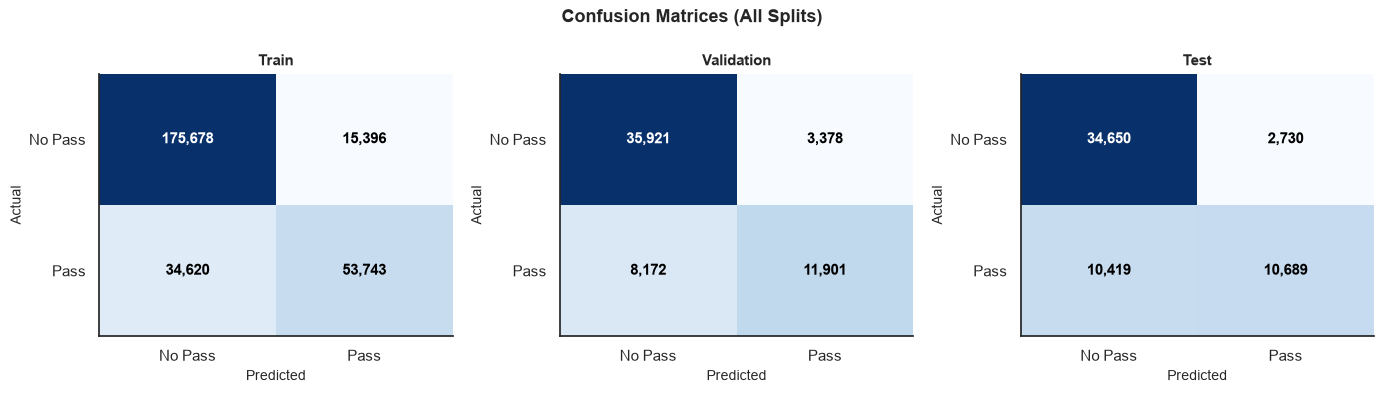

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

results_by_split = [
    ("Train", train_results),
    ("Validation", val_results),
    ("Test", test_results),
]

for ax, (name, results) in zip(axes, results_by_split):
    cm = [
        [results["tn"], results["fp"]],
        [results["fn"], results["tp"]],
    ]

    ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Pass", "Pass"])
    ax.set_yticklabels(["No Pass", "Pass"])
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    keep_main_axes(ax)

    max_val = max(max(row) for row in cm)
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i][j] > max_val / 2 else "black"
            ax.text(
                j,
                i,
                f"{cm[i][j]:,}",
                ha="center",
                va="center",
                color=color,
                fontsize=11,
                fontweight="bold",
            )

plt.suptitle("Confusion Matrices (All Splits)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Understanding Confusion Matrices

Each cell shows predictions versus actual labels:

```text
           Predicted
           No Pass  Pass
Actual No  TN       FP
Actual Pass FN      TP
```

- **True Negatives:** correctly predicted no-pass windows.
- **False Positives:** no-pass windows incorrectly predicted as passes.
- **False Negatives:** actual passes the model missed.
- **True Positives:** correctly predicted pass windows.

The trade-off is important: lowering the decision threshold can catch
more passes, but it will usually create more false positives.

## Leakage Check

Event coordinate columns from the master join are intentionally excluded
from the training table and model features. This keeps the pass detector
from using the location of an already-labelled event to predict whether
the window contains a pass.

In [53]:
event_coordinate_columns = [
    "e.x_meters_absolute",
    "e.y_meters_absolute",
]

audit_rows = []
for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    present = [column for column in event_coordinate_columns if column in df.columns]
    audit_rows.append(
        {
            "split": split_name,
            "event_coordinate_columns_present": ", ".join(present) if present else "none",
            "leakage_removed": len(present) == 0,
        }
    )

leakage_audit_df = pd.DataFrame(audit_rows)
display(leakage_audit_df)

if any(~leakage_audit_df["leakage_removed"]):
    raise AssertionError("Event coordinate leakage columns are still present.")

print("Event coordinate leakage columns are absent from all model splits.")

,split,event_coordinate_columns_present,leakage_removed
0,Train,none,True
1,Validation,none,True
2,Test,none,True


Event coordinate leakage columns are absent from all model splits.


**Interpretation**

The model still uses `primary_event` only to create the target and to
evaluate the labelled data. It does not receive event coordinate
columns as input features.

## Model Summary

**Performance**

- Use ROC-AUC to judge how well the model ranks pass windows above
  no-pass windows.
- Use F1-score to judge the balance between catching passes and avoiding
  false alarms.
- Compare train, validation, and test to check overfitting.

**What the model currently uses**

1. `ball_speed_avg_xy` — average 2D ball speed across the 5-frame window
   in metres per frame.
2. `closest_player_team_id` — which team's player was closest to the ball at
   the primary event frame (label-encoded integer; `0` = no visible player or
   no-event window).

**Next steps**

- Add more features from the training table (e.g. `window_time`, `t.period`,
  player count near ball, ball direction).
- Tune hyperparameters such as `max_depth` and `learning_rate`.
- Add class-imbalance handling with `scale_pos_weight`.
- Analyze false positives and false negatives.
- Monitor performance on new matches over time.